# Analisis Sentimen (Bahasa Indonesia): Autolabel LLM + SVM

Notebook ini memuat data (kolom `full_text`), preprocessing untuk teks media sosial, autolabel LLM lewat **OpenRouter** (hanya **sentimen**: positif / netral / negatif), pelatihan **SVM** dengan **GridSearchCV**, pencarian kombinasi **train/test split** terbaik, evaluasi (**confusion matrix**, **classification report**), dan **wordcloud**. Artefak diekspor ke folder lalu dibuat satu file ZIP.

## 1. Instalasi dependensi

Jalankan sekali di terminal proyek (atau uncomment baris pip di bawah) jika paket belum terpasang.

## 3. Fungsi Penghitung Token

Fungsi `count_tokens` akan digunakan untuk estimasi jumlah token, menggunakan `tiktoken` jika tersedia, atau perkiraan berdasarkan panjang string.

In [1]:
%%writefile requirements.txt
openai
Sastrawi
pandas
scikit-learn
matplotlib
seaborn
wordcloud

Writing requirements.txt


In [2]:
!pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.6 MB/s eta 0:00:00


In [3]:
!pip install mega.py -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-core 1.2.23 requires tenacity!=8.4.0,<10.0.0,>=8.1.0, but you have tenacity 5.1.5 which is incompatible.
google-adk 1.28.0 requires tenacity<10.0.0,>=9.0.0, but you have tenacity 5.1.5 which is incompatible.
google-genai 1.68.0 requires tenacity<9.2.0,>=8.2.3, but you have tenacity 5.1.5 which is incompatible.
pyiceberg 0.11.1 requires tenacity<10.0.0,>=8.2.3, but you have tenacity 5.1.5 which is incompatible.
plotly 5.24.1 requires tenacity>=6.2.0, but you have tenacity 5.1.5 which is incompatible.


In [4]:
!pip install tenacity>=5.1.5 --upgrade

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mega-py 1.0.8 requires tenacity<6.0.0,>=5.1.5, but you have tenacity 9.1.4 which is incompatible.


In [5]:
from mega import Mega
mega = Mega()
m = mega.login()

file_url = "https://mega.nz/file/TFMlhawC#30-4wbN06JboWovurgIyQeAApQVwMTU8PaTNiIZ8zjg"
file_id = file_url.split('/')[-1].split('#')[0]
downloaded_file = m.download_url(file_url)
print(f"File downloaded to: {downloaded_file}")

File downloaded to: Spaylater X Scraping fix2.xlsx


In [6]:
import os

# Set API Key OpenRouter
os.environ["OPENROUTER_API_KEY"] = "REDACTED"

## 2. Impor pustaka dan konfigurasi

Mengatur variabel lingkungan `OPENROUTER_API_KEY`, batas token batch LLM, path CSV, dan folder ekspor.

In [7]:
import ast
import json
import os
import re
import unicodedata
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from openai import OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from wordcloud import WordCloud

warnings.filterwarnings("ignore", category=UserWarning)

# --- Konfigurasi ---
CSV_PATH = Path("Spaylater X Scraping fix2.xlsx")  # ganti ke file Anda
EXPORT_DIR = Path("exports_sentimen")
RAW_RESPONSE_DIR = Path("raw_response")  # respons mentah LLM: 001_raw_response_<kode_acak>.txt
MAX_TOKEN_DATA = 30000  # target maksimum token INPUT per batch (estimasi tiktoken)
MAX_LLM_BATCH_ITEMS = 80  # maks jumlah teks per panggilan LLM (hindari respons terpotong)
LLM_MAX_OUTPUT_TOKENS = 512  # batas keluaran API; naikkan jika batch besar atau JSON panjang
OPENROUTER_BASE = "https://openrouter.ai/api/v1"
LLM_MODEL = "nvidia/nemotron-3-super-120b-a12b:free"  # bisa diganti model lain di OpenRouter

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

In [8]:
try:
    import tiktoken

    enc = tiktoken.get_encoding("cl100k_base")

    def count_tokens(s: str) -> int:
        return len(enc.encode(s))
except Exception:
    def count_tokens(s: str) -> int:
        return max(1, int(len(s) / 4))


## 3. Muat dataset

Membaca Excel/CSV; diasumsikan minimal ada kolom `full_text`. Jika sudah ada kolom `label`, autolabel LLM dilewati.

In [9]:
df = pd.read_excel(CSV_PATH)
print(df.head())
assert "full_text" in df.columns, "File harus memiliki kolom 'full_text'"
df.head()

                                           full_text
0  fyi ใครเลือกผ่อน shopee หลายๆเดือนไป แล้ววันนึ...
1  💚 ada transaksi di akun shopee adekku segini m...
2  Rekomendasi Dompet on Shopee 🌼\n\n— a thread h...
3  shopeeのレビュー率マジでバグってるw\n国内物販やってる人にはわかる異常値🤣 http...
4  Spaylater di Shopee ada processing fee tau. Ma...


,full_text
0,fyi ใครเลือกผ่อน shopee หลายๆเดือนไป แล้ววันนึ...
1,💚 ada transaksi di akun shopee adekku segini m...
2,Rekomendasi Dompet on Shopee 🌼\n\n— a thread h...
3,shopeeのレビュー率マジでバグってるw\n国内物販やってる人にはわかる異常値🤣 http...
4,Spaylater di Shopee ada processing fee tau. Ma...


In [10]:
# sampling
LEN_SAMPLE_DATA = 300
# Mengambil 100 baris secara acak
df_sampled = df.sample(n=LEN_SAMPLE_DATA, random_state=42)
df = df_sampled

In [11]:
df["token_count"] = df["full_text"].apply(count_tokens)
total_tokens = df["token_count"].sum()
print(f"Total token dalam DataFrame: {total_tokens}")

Total token dalam DataFrame: 26028


<Axes: title={'center': 'Histogram Token Count'}, ylabel='Frequency'>

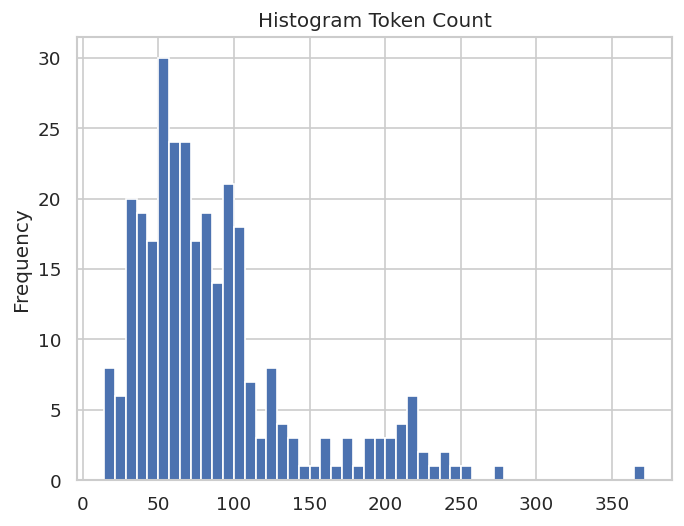

In [12]:
df["token_count"].plot(kind="hist", bins=50, title="Histogram Token Count")

In [13]:
len(df)

300

## 4. Preprocessing (fungsi lengkap untuk teks media sosial)

Langkah umum: normalisasi Unicode, huruf kecil, hapus URL/email, normalisasi mention/hashtag, kurangi perulangan karakter berlebihan, rapikan spasi, kamus singkatan ringan bahasa Indonesia, lalu **penghapusan stopword** dan **stemming** dengan pustaka **Sastrawi** (urutan: hapus stopword → stem).

In [14]:
# Kamus singkatan umum (bisa diperluas)
SLANG_MAP = {
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "yg": "yang",
    "dgn": "dengan",
    "utk": "untuk",
    "krn": "karena",
    "jd": "jadi",
    "tp": "tapi",
    "tpi": "tapi",
    "sm": "sama",
    "bgt": "banget",
    "banget": "banget",
    "trs": "terus",
    "knp": "kenapa",
    "sy": "saya",
    "gue": "saya",
    "lu": "kamu",
    "udh": "sudah",
    "udah": "sudah",
}

URL_RE = re.compile(r"http\S+|www\.\S+")
EMAIL_RE = re.compile(r"[\w.-]+@[\w.-]+")
MENTION_RE = re.compile(r"@\w+")
MULTISPACE_RE = re.compile(r"\s+")
REPEAT_CHAR_RE = re.compile(r"(.)\1{2,}")

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

_factory_sw = StopWordRemoverFactory()
_stopword_remover = _factory_sw.create_stop_word_remover()
_factory_stem = StemmerFactory()
_stemmer = _factory_stem.create_stemmer()


def expand_slang_tokens(text: str) -> str:
    toks = text.split()
    out = [SLANG_MAP.get(t, t) for t in toks]
    return " ".join(out)


def apply_sastrawi_stopword_and_stem(text: str) -> str:
    """Hapus stopword lalu stem dengan Sastrawi (Bahasa Indonesia)."""
    if not text or not str(text).strip():
        return text if isinstance(text, str) else str(text)
    t = _stopword_remover.remove(text)
    t = MULTISPACE_RE.sub(" ", t).strip()
    if not t:
        return ""
    t = _stemmer.stem(t)
    return MULTISPACE_RE.sub(" ", str(t)).strip()


def preprocess_text(text: str, remove_digits: bool = False, use_sastrawi: bool = True) -> str:
    if not isinstance(text, str):
        text = str(text)
    # Unicode NFKC
    t = unicodedata.normalize("NFKC", text)
    t = t.strip()
    # URL & email
    t = URL_RE.sub(" ", t)
    t = EMAIL_RE.sub(" ", t)
    # Mention → token umum (pertahankan konteks bahwa ada mention)
    t = MENTION_RE.sub(" mention ", t)
    # Hashtag: pertahankan kata tanpa #
    t = re.sub(r"#(\w+)", r"\1", t)
    # Huruf kecil
    t = t.lower()
    # Angka opsional
    if remove_digits:
        t = re.sub(r"\d+", " ", t)
    # Tanda baca berlebih → spasi
    t = re.sub(r"[\[\](){}\[\]<>]", " ", t)
    # Ulang karakter berlebihan (mis. "bagusssss" → "bagus")
    t = REPEAT_CHAR_RE.sub(r"\1\1", t)
    t = MULTISPACE_RE.sub(" ", t).strip()
    # Singkatan
    t = expand_slang_tokens(t)
    if use_sastrawi:
        t = apply_sastrawi_stopword_and_stem(t)
    return t


def preprocess_series(series: pd.Series, **kwargs) -> pd.Series:
    return series.astype(str).map(lambda x: preprocess_text(x, **kwargs))

## 5. Demo preprocessing langkah demi langkah (5 sampel)

Menampilkan teks asli vs hasil tiap tahap agar mudah diaudit.

In [15]:
sample_n = min(5, len(df))
samples = df["full_text"].head(sample_n)

def demo_steps(raw: str) -> None:
    print("=== ASLI ===")
    print(raw)
    s = unicodedata.normalize("NFKC", raw).strip()
    print("\n--- setelah Unicode + strip ---")
    print(s)
    s = URL_RE.sub(" ", s)
    s = EMAIL_RE.sub(" ", s)
    print("\n--- hapus URL/email ---")
    print(s)
    s = MENTION_RE.sub(" mention ", s)
    s = re.sub(r"#(\w+)", r"\1", s)
    print("\n--- mention & hashtag ---")
    print(s)
    s = s.lower()
    print("\n--- lower ---")
    print(s)
    s = re.sub(r"[\[\](){}\[\]<>]", " ", s)
    s = REPEAT_CHAR_RE.sub(r"\1\1", s)
    s = MULTISPACE_RE.sub(" ", s).strip()
    print("\n--- tanda & repeat char ---")
    print(s)
    s = expand_slang_tokens(s)
    print("\n--- setelah singkatan (slang) ---")
    print(s)
    s = _stopword_remover.remove(s)
    s = MULTISPACE_RE.sub(" ", s).strip()
    print("\n--- hapus stopword (Sastrawi) ---")
    print(s)
    s = _stemmer.stem(s) if s else ""
    s = MULTISPACE_RE.sub(" ", str(s)).strip()
    print("\n--- stemming (Sastrawi) --- FINAL ---")
    print(s)
    print()

for i, raw in enumerate(samples, 1):
    print(f"######## Sampel {i} ########")
    demo_steps(str(raw))

######## Sampel 1 ########
=== ASLI ===
S͙n͙o͙w͙ A͙n͙g͙e͙l͙
͙
͙T͙Y͙F͙T͙T͙

@___SPAZ___ 

C͎o͎m͎e͎ f͎o͎l͎l͎o͎w͎ t͎h͎e͎ b͎e͎s͎t͎
͎@___SPAZ___ 
͎T͎h͎a͎n͎k͎ y͎o͎u͎ f͎o͎r͎ i͎n͎c͎l͎u͎d͎i͎n͎g͎ m͎e͎ w͎i͎t͎h͎ g͎r͎e͎a͎t͎ P͎a͎t͎r͎i͎o͎t͎s͎!͎!͎ https://t.co/QiuoW5SjAo

--- setelah Unicode + strip ---
S͙n͙o͙w͙ A͙n͙g͙e͙l͙
͙
͙T͙Y͙F͙T͙T͙

@___SPAZ___ 

C͎o͎m͎e͎ f͎o͎l͎l͎o͎w͎ t͎h͎e͎ b͎e͎s͎t͎
͎@___SPAZ___ 
͎T͎h͎a͎n͎k͎ y͎o͎u͎ f͎o͎r͎ i͎n͎c͎l͎u͎d͎i͎n͎g͎ m͎e͎ w͎i͎t͎h͎ g͎r͎e͎a͎t͎ P͎a͎t͎r͎i͎o͎t͎s͎!͎!͎ https://t.co/QiuoW5SjAo

--- hapus URL/email ---
S͙n͙o͙w͙ A͙n͙g͙e͙l͙
͙
͙T͙Y͙F͙T͙T͙

@___SPAZ___ 

C͎o͎m͎e͎ f͎o͎l͎l͎o͎w͎ t͎h͎e͎ b͎e͎s͎t͎
͎@___SPAZ___ 
͎T͎h͎a͎n͎k͎ y͎o͎u͎ f͎o͎r͎ i͎n͎c͎l͎u͎d͎i͎n͎g͎ m͎e͎ w͎i͎t͎h͎ g͎r͎e͎a͎t͎ P͎a͎t͎r͎i͎o͎t͎s͎!͎!͎  

--- mention & hashtag ---
S͙n͙o͙w͙ A͙n͙g͙e͙l͙
͙
͙T͙Y͙F͙T͙T͙

 mention  

C͎o͎m͎e͎ f͎o͎l͎l͎o͎w͎ t͎h͎e͎ b͎e͎s͎t͎
͎ mention  
͎T͎h͎a͎n͎k͎ y͎o͎u͎ f͎o͎r͎ i͎n͎c͎l͎u͎d͎i͎n͎g͎ m͎e͎ w͎i͎t͎h͎ g͎r͎e͎a͎t͎ P͎a͎t͎r͎i͎o͎t͎s͎!͎!͎  

--- lower ---
s͙n͙o͙w͙ a͙n͙g͙e͙l͙
͙
͙t͙y͙f͙t͙t͙

 mention 

## 6. Terapkan preprocessing ke seluruh data

Kolom baru `text_clean` dipakai untuk vektorisasi SVM (sudah termasuk stopword + stemming Sastrawi). Autolabel LLM memakai **`full_text`** (asli) hanya untuk **sentimen**. Untuk mematikan Sastrawi, panggil `preprocess_series(..., use_sastrawi=False)`.

In [16]:
df["text_clean"] = preprocess_series(df["full_text"], remove_digits=False)
df[["full_text", "text_clean"]].head()

,full_text,text_clean
96,S͙n͙o͙w͙ A͙n͙g͙e͙l͙\n͙\n͙T͙Y͙F͙T͙T͙\n\n@___SPA...,s n o w a n g e l t y f t t mention c o m e f ...
994,🍃 sender pngn puk puk sakura😭😭😭😭😭😭 https://t.c...,sender pngn puk puk sakura
1400,🎉🚨🔥🎉🚨🔥🎉🚨🔥🎉🚨🔥\n\nAnd here what happened since D...,and here what happened since december 24 until...
865,@thato_nmv You wouldn’t want to miss it #Festi...,mention you wouldn t want to miss it festiveph...
6097,Review แลก #spaylater ย้อนหลัง รับตลอด รับไม่อ...,review spaylater 500 2 00 ss likes spay


## 7. Autolabel dengan LLM (batch mendekati `MAX_TOKEN_DATA` + batas `MAX_LLM_BATCH_ITEMS`)

Batch dibatasi **token input** dan **jumlah baris** agar respons tidak terpotong. Untuk setiap `full_text`, model mengembalikan **hanya** **sentimen** (`positif` / `netral` / `negatif`). Format balasan: **satu array JSON** berisi string label saja, urutan identik dengan input, misalnya `["negatif", "netral", "positif", ...]`. Tanpa objek, tanpa terjemahan. Setiap respons mentah API disimpan ke folder `raw_response` dengan nama `001_raw_response_<kode_acak>.txt`, `002_...`, dst. (urutan panggilan). Jika parsing gagal, batch **otomatis dipecah** dan diulang. Jika output sering terpotong, turunkan `MAX_LLM_BATCH_ITEMS` atau naikkan `LLM_MAX_OUTPUT_TOKENS`. Jika API mengembalikan **`RateLimitError`**, progres disimpan ke `exports_sentimen/autolabel_partial_ratelimit_<timestamp>.csv` dan sisa baris mendapat label kosong (`NA`) — lanjutkan nanti atau filter sebelum latih SVM.

In [ ]:
try:
    import tiktoken

    enc = tiktoken.get_encoding("cl100k_base")

    def count_tokens(s: str) -> int:
        return len(enc.encode(s))
except Exception:

    def count_tokens(s: str) -> int:
        return max(1, int(len(s) / 4))

from openai import RateLimitError
import secrets

SYNONYMS = {
    "positif": "positif",
    "positive": "positif",
    "netral": "netral",
    "neutral": "netral",
    "negatif": "negatif",
    "negative": "negatif",
}


def normalize_one_label(s: str) -> str:
    key = str(s).strip().lower().strip("'\"'") # Fixed: Changed from strip("'"") to strip("'\"'")
    key = re.sub(r"^\d+[).\s]+", "", key).strip()
    key = re.sub(r"^[-*•]\s*", "", key).strip()
    if key not in SYNONYMS:
        raise ValueError(f"Label tidak dikenal: {s!r}")
    return SYNONYMS[key]


def strip_code_fence(text: str) -> str:
    t = text.strip()
    if t.startswith("```"):
        t = re.sub(r"^```[a-zA-Z]*\n?", "", t)
        t = re.sub(r"```$", "", t).strip()
    return t


def extract_first_json_array(text: str) -> str | None:
    """Ambil substring array JSON pertama dengan penghitungan bracket (tahan teks sampah sebelum/sesudah)."""
    start = text.find("[")
    if start == -1:
        return None
    depth = 0
    in_string = False
    escape = False
    quote = ""
    for i in range(start, len(text)):
        ch = text[i]
        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == quote:
                in_string = False
            continue
        if ch in "\"'":
            in_string = True
            quote = ch
            continue
        if ch == "[":
            depth += 1
        elif ch == "]":
            depth -= 1
            if depth == 0:
                return text[start : i + 1]
    return None


def parse_llm_sentiment_labels_json(content: str, n_expected: int) -> list[str]:
    """Parse array JSON: ["positif"|"netral"|"negatif", ...] urutan = input (hanya string label)."""
    raw = strip_code_fence(content).strip()
    arr = None
    try:
        arr = json.loads(raw)
    except json.JSONDecodeError:
        pass
    if not isinstance(arr, list) or len(arr) != n_expected:
        blob = extract_first_json_array(raw)
        if blob:
            try:
                arr = json.loads(blob)
            except json.JSONDecodeError as e:
                raise ValueError(
                    f"JSON tidak bisa di-parse: {e}. Awal respons: {raw[:400]!r}"
                ) from e
        else:
            i0 = raw.find("[")
            i1 = raw.rfind("]")
            if i0 != -1 and i1 > i0:
                try:
                    arr = json.loads(raw[i0 : i1 + 1])
                except json.JSONDecodeError as e:
                    raise ValueError(
                        f"JSON tidak bisa di-parse: {e}. Awal respons: {raw[:400]!r}"
                    ) from e
    if not isinstance(arr, list) or len(arr) != n_expected:
        raise ValueError(
            f"Tidak bisa parse tepat {n_expected} label (dapat len={len(arr) if isinstance(arr, list) else 'n/a'}). "
            f"Awal respons: {raw[:500]!r}"
        )
    labels: list[str] = []
    for i, item in enumerate(arr):
        if isinstance(item, str):
            labels.append(normalize_one_label(item))
        elif isinstance(item, dict):
            lab = item.get("label")
            if lab is None:
                lab = item.get("sentimen")
            if lab is None:
                raise ValueError(f"Elemen {i} objek tanpa label: {item!r}")
            labels.append(normalize_one_label(str(lab)))
        else:
            raise ValueError(f"Elemen {i} harus string label atau objek {{\"label\":...}}: {item!r}")
    return labels


def build_batches(
    texts: list[str],
    max_tokens: int,
    max_items: int | None = None,
) -> list[list[str]]:
    batches: list[list[str]] = []
    cur: list[str] = []
    cur_tokens = 0
    overhead = 120
    for t in texts:
        tok = count_tokens(t)
        over_tokens = cur and (cur_tokens + tok + overhead > max_tokens)
        over_items = cur and max_items is not None and (len(cur) >= max_items)
        if over_tokens or over_items:
            batches.append(cur)
            cur = []
            cur_tokens = 0
        cur.append(t)
        cur_tokens += tok
    if cur:
        batches.append(cur)
    return batches


_llm_raw_export_seq = 0


def _reset_llm_raw_export_counter() -> None:
    global _llm_raw_export_seq
    _llm_raw_export_seq = 0


def _save_llm_raw_response_body(text: str) -> None:
    global _llm_raw_export_seq
    _llm_raw_export_seq += 1
    RAW_RESPONSE_DIR.mkdir(parents=True, exist_ok=True)
    code = secrets.token_hex(4)
    fname = f"{_llm_raw_export_seq:03d}_raw_response_{code}.txt"
    (RAW_RESPONSE_DIR / fname).write_text(text, encoding="utf-8")


def _call_llm_sentiment_batch_once(client: OpenAI, batch_texts: list[str]) -> list[str]:
    n = len(batch_texts)
    joined = json.dumps(batch_texts, ensure_ascii=False)
    system = (
        "Anda hanya mengeluarkan daftar label sentimen dalam bentuk JSON. Aturan mutlak:\n"
        f"- Input user adalah satu array JSON berisi {n} string (teks sosial media).\n"
        f"- Output Anda HANYA satu array JSON dengan tepat {n} elemen. Tidak ada teks lain.\n"
        "- Tiap elemen hanya salah satu kata: positif, netral, atau negatif (huruf kecil).\n"
        "- Urutan elemen = urutan teks input (indeks 0 = item pertama).\n"
        "- Jika teks menyentuh SpayLater, ShopeePay, Shopee, atau e-wallet, nilai sentimen "
        "mengacu ke opini tentang hal itu; jika tidak relevan, nilai sentimen untuk keseluruhan kalimat.\n"
        "LARANG keras: penjelasan, alasan, nomor urut, 'We need', 'First text', langkah berpikir, "
        "markdown, code fence ```, atau karakter apa pun sebelum '[' atau setelah ']'.\n"
        "Karakter pertama jawaban harus '['; karakter terakhir harus ']'."
    )
    user = (
        f"Klasifikasikan sentimen tiap elemen. Balas HANYA array JSON {n} label, tanpa prefiks/sufiks.\n"
        f"{joined}"
    )
    resp = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        temperature=0,
        max_tokens=LLM_MAX_OUTPUT_TOKENS,
    )
    choice = resp.choices[0]
    raw = (choice.message.content or "").strip()
    _save_llm_raw_response_body(raw)
    if not raw:
        raise ValueError("LLM mengembalikan konten kosong")
    return parse_llm_sentiment_labels_json(raw, n)


def call_llm_sentiment_batch(client: OpenAI, batch_texts: list[str]) -> list[str]:
    if not batch_texts:
        return []
    try:
        return _call_llm_sentiment_batch_once(client, batch_texts)
    except RateLimitError:
        raise
    except Exception as e:
        if len(batch_texts) == 1:
            raise
        mid = len(batch_texts) // 2
        print(f"  (!) Batch {len(batch_texts)} item gagal, pecah jadi {mid} + {len(batch_texts)-mid}: {e}")
        a1 = call_llm_sentiment_batch(client, batch_texts[:mid])
        a2 = call_llm_sentiment_batch(client, batch_texts[mid:])
        return a1 + a2


def autolabel_dataframe(df_in: pd.DataFrame, text_col: str = "full_text") -> pd.Series:
    _reset_llm_raw_export_counter()
    client = OpenAI(base_url=OPENROUTER_BASE, api_key=os.environ["OPENROUTER_API_KEY"])
    texts = df_in[text_col].astype(str).tolist()
    batches = build_batches(texts, MAX_TOKEN_DATA, max_items=MAX_LLM_BATCH_ITEMS)
    print(
        f"Pembagian batch: {len(batches)} batch "
        f"(\u2264{MAX_TOKEN_DATA} tok/input estimasi, \u2264{MAX_LLM_BATCH_ITEMS} item/batch)"
    )
    for bi, batch in enumerate(batches, 1):
        approx_tok = sum(count_tokens(t) for t in batch)
        print(f"  Batch {bi}: {len(batch)} teks, ~{approx_tok} token input")
    all_labels: list[str] = []
    try:
        for bi, batch in enumerate(batches, 1):
            print(f"Memanggil LLM: batch {bi}/{len(batches)}, item={len(batch)}")
            labs = call_llm_sentiment_batch(client, batch)
            all_labels.extend(labs)
    except RateLimitError as e:
        print(f"(!) RateLimitError dari API: {e}")
        print("    Menyimpan progres ke disk; baris berikutnya tanpa label (kosong / NA).")
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        n_done = len(all_labels)
        n_total = len(df_in)
        rest = [pd.NA] * (n_total - n_done)
        partial = pd.Series(all_labels + rest, index=df_in.index, dtype="object")
        out_df = df_in.copy()
        out_df["label"] = partial
        out_path = EXPORT_DIR / f"autolabel_partial_ratelimit_{ts}.csv"
        out_df.to_csv(out_path, index=False)
        print(f"    Tersimpan: {out_path.resolve()} (label terisi: {n_done}/{n_total})")
        return partial
    return pd.Series(all_labels, index=df_in.index)


if "label" in df.columns:
    print("Kolom 'label' ada \u2014 melewati autolabel LLM.")
    df["label"] = df["label"].astype(str).str.strip().str.lower()
    syn = {"positive": "positif", "neutral": "netral", "negative": "negatif"}
    df["label"] = df["label"].replace(syn)
    allowed = {"positif", "netral", "negatif"}
    bad = set(df["label"].unique()) - allowed
    if bad:
        raise ValueError(f"Label tidak dikenal setelah normalisasi: {bad}")
else:
    if not os.environ.get("OPENROUTER_API_KEY"):
        raise RuntimeError("Set OPENROUTER_API_KEY untuk autolabel LLM (atau tambahkan kolom 'label' di CSV).")
    print("Autolabel dengan LLM \u2026")
    lab_s = autolabel_dataframe(df, text_col="full_text")
    df["label"] = lab_s

label_list = df["label"].astype(str).tolist()
print("Contoh daftar label (10 pertama):", label_list[:10])
df[["full_text", "text_clean", "label"]].head(10)


## 8. Encoding label & pencarian split + hyperparameter SVM

Menggunakan **Pipeline** `TfidfVectorizer` + `SVC`, **GridSearchCV** pada data latih, dan **grid** nilai `test_size` untuk memilih pembagian data uji yang memberi akurasi uji terbaik (setelah grid SVM pada train).

In [ ]:
label_to_id = {"negatif": 0, "netral": 1, "positif": 2}
id_to_label = {v: k for k, v in label_to_id.items()}
y = df["label"].map(label_to_id).astype(int)
X = df["text_clean"]

split_grid = [0.15, 0.2, 0.25, 0.3]
random_state = 42

pipe = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_df=0.95)),
        ("svc", SVC(kernel="linear", class_weight="balanced")),
    ]
)

param_grid = {
    "tfidf__max_features": [3000, 5000],
    "svc__C": [0.5, 1, 2],
}

# StratifiedKFold: n_splits tidak boleh melebihi jumlah sampel kelas paling jarang
min_class = int(y.value_counts().min())
if min_class < 2:
    raise ValueError("Setiap kelas minimal 2 sampel agar stratified CV valid.")
n_splits_cv = min(5, min_class)
cv_inner = StratifiedKFold(n_splits=n_splits_cv, shuffle=True, random_state=random_state)

best = {"score": -1.0, "test_size": None, "model": None, "X_test": None, "y_test": None, "X_train": None, "y_train": None}

for ts in split_grid:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=ts, stratify=y, random_state=random_state
    )
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_tr, y_tr)
    acc = grid.score(X_te, y_te)
    print(f"test_size={ts:.2f} | best CV acc={grid.best_score_:.4f} | holdout acc={acc:.4f} | params={grid.best_params_}")
    if acc > best["score"]:
        best.update(
            {
                "score": acc,
                "test_size": ts,
                "model": grid.best_estimator_,
                "X_test": X_te,
                "y_test": y_te,
                "X_train": X_tr,
                "y_train": y_tr,
                "best_params": grid.best_params_,
                "cv_score": grid.best_score_,
            }
        )

print("\nSplit & model terbaik (holdout acc):", best["test_size"], best["score"])
final_model = best["model"]
X_test, y_test = best["X_test"], best["y_test"]

## 9. Confusion matrix dan classification report

Evaluasi pada hold-out split terpilih.

In [ ]:
y_pred = final_model.predict(X_test)
labels_order = [0, 1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
target_names = [id_to_label[i] for i in labels_order]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
ax.set_title("Confusion Matrix")
plt.tight_layout()

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
cm_path = EXPORT_DIR / f"confusion_matrix_{ts}.png"
fig.savefig(cm_path, bbox_inches="tight")
plt.show()

report_str = classification_report(
    y_test, y_pred, target_names=target_names, zero_division=0
)
print(report_str)

report_path = EXPORT_DIR / f"classification_report_{ts}.txt"
report_path.write_text(report_str, encoding="utf-8")

## 10. Wordcloud keseluruhan teks bersih

Frekuensi kata dari `text_clean` (gabungan semua baris).

In [ ]:
text_blob = " ".join(df["text_clean"].astype(str).tolist())
wc = WordCloud(width=900, height=500, background_color="white", colormap="viridis", max_words=200).generate(text_blob)
plt.figure(figsize=(9, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud (text_clean)")
wc_path = EXPORT_DIR / f"wordcloud_{ts}.png"
plt.tight_layout()
plt.savefig(wc_path, bbox_inches="tight")
plt.show()

## 11. Simpan tabel & ringkasan, lalu buat satu file ZIP

Menyimpan CSV berlabel, contoh preprocessing, metrik, dan gambar ke folder `exports_sentimen`, kemudian mengompresi menjadi `sentimen_export_<timestamp>.zip`.

In [ ]:
# Simpan dataframe dengan label
csv_out = EXPORT_DIR / f"dataset_dengan_label_{ts}.csv"
df.to_csv(csv_out, index=False)

# Simpan sample preprocessing 5 baris
cols_prev = ["full_text", "text_clean"]
if "label" in df.columns:
    cols_prev.append("label")
sample_prev = df[cols_prev].head(5)
sample_prev.to_csv(EXPORT_DIR / f"sample_preprocessing_{ts}.csv", index=False)

summary = {
    "best_test_size": best["test_size"],
    "holdout_accuracy": float(best["score"]),
    "best_cv_accuracy": float(best["cv_score"]),
    "best_params": best["best_params"],
    "n_samples": int(len(df)),
    "timestamp": ts,
}
(EXPORT_DIR / f"summary_{ts}.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

zip_name = Path(f"sentimen_export_{ts}.zip")
added = set()
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in EXPORT_DIR.iterdir():
        if p.is_file() and p.suffix and p.name not in added:
            zf.write(p, arcname=p.name)
            added.add(p.name)

print("ZIP dibuat:", zip_name.resolve())
print("Isi folder ekspor:", list(EXPORT_DIR.iterdir()))

## Catatan penggunaan

1. Set `OPENROUTER_API_KEY` di lingkungan sebelum menjalankan autolabel.
2. Ganti `CSV_PATH` dan `LLM_MODEL` sesuai kebutuhan.
3. Jika data sudah berlabel di kolom `label`, pastikan nilainya `positif` / `netral` / `negatif` (sinonim Inggris akan dinormalisasi).
4. Dataset dummy kecil — untuk penelitian, ganti dengan data lebih besar dan sesuaikan `MAX_TOKEN_DATA` serta grid hyperparameter.
5. `Sastrawi` dipakai untuk stopword dan stemming; pastikan terpasang (`pip install Sastrawi`).
6. Autolabel: respons berupa array JSON string saja, mis. `["negatif","netral","positif",...]` (urutan = input). Jika terpotong, turunkan `MAX_LLM_BATCH_ITEMS` (mis. 8–12) atau naikkan `LLM_MAX_OUTPUT_TOKENS`.